# EDA – Muskel-Segmentierung (nach DAW / `cleaned_data_2`)

Explorative Analyse der **bereinigten** GCAP-Kohorte vor dem DLBS-Baseline-Training.

**Fokus:** Label-Verteilung, Datenqualität, Geometrie, Klassen-Imbalance — relevant für 3D-Patch-Training (aktuell **rechtes** Bein, Labels 9–16 → remapped 1–8 in DLBS).

**Daten:** `code/cleaned_data_2` (Masken/Water je Subject-Unterordner; im Notebook via `DATA_ROOT` geladen).  
**Training (DLBS):** siehe `../splits/folds.json` — **10 Subjects**, 3-Fold CV, rechtes Bein; keine manuellen Ausschlüsse in der aktuellen Kohorte.

Die **Zahlen in den Tabellen/Plots** stammen aus der Ausführung dieses Notebooks; interpretierende Texte unten beziehen sich auf die aktuellen Outputs.

In [1]:
import json, os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.0)

PROJECT_ROOT = Path('..').resolve()  # deep_learning_bild/
RESULTS = PROJECT_ROOT / 'results'
# Kanonisch: code/cleaned_data_2 (train.py); Fallback: deep_learning_bild/data/
DATA_ROOT = (PROJECT_ROOT.parent / 'cleaned_data_2').resolve()
if not (DATA_ROOT / 'masks').is_dir():
    DATA_ROOT = PROJECT_ROOT / 'data'
MASK_DIR = DATA_ROOT / 'masks'
WATER_DIR = DATA_ROOT / 'water'
SPLITS_PATH = PROJECT_ROOT / 'splits' / 'folds.json'

# ── label mapping (primary: 1-8 = links, 9-12 = rechts quad; right-file: 9-16) ──
LABEL_NAMES = {
    0:  'BG',
    1:  'VL_L',   2:  'RF_L',   3:  'VM_L',   4:  'VI_L',
    5:  'BfSH_L', 6:  'BfLH_L', 7:  'ST_L',   8:  'SM_L',
    9:  'VL_R',   10: 'RF_R',   11: 'VM_R',   12: 'VI_R',
    13: 'BfSH_R', 14: 'BfLH_R', 15: 'ST_R',   16: 'SM_R',
}
MUSCLE_LABELS = list(range(1, 17))

def muscle_group(l):
    if l in range(1, 5):   return 'Quad L'
    if l in range(5, 9):   return 'Hamstr L'
    if l in range(9, 13):  return 'Quad R'
    if l in range(13, 17): return 'Hamstr R'
    return 'BG'

GROUP_COL = {'Quad L':'#4C72B0','Hamstr L':'#DD8452','Quad R':'#55A868','Hamstr R':'#C44E52'}
LABEL_COL  = {l: GROUP_COL[muscle_group(l)] for l in MUSCLE_LABELS}

def load_mask(path):
    """Return mask array; returns None if file is unreadable."""
    try:
        return np.asarray(nib.load(str(path)).dataobj)
    except Exception:
        return None

print('Setup ok.')

# DLBS-Kohorte (nach Annotation-Audit, für 3-Fold-CV)
if SPLITS_PATH.exists():
    _folds_meta = json.loads(SPLITS_PATH.read_text())['meta']
    CV_SUBJECTS = _folds_meta.get('subjects', [])
    CV_EXCLUDED = _folds_meta.get('excluded_subjects') or _folds_meta.get('excluded', [])
    print(f'DLBS CV: {len(CV_SUBJECTS)} Subjects, ausgeschlossen: {CV_EXCLUDED}')
else:
    CV_SUBJECTS, CV_EXCLUDED = [], []


Setup ok.
DLBS CV: 10 Subjects, ausgeschlossen: []


---
## 1 · Datei-Inventar – welche IDs haben welche Masken?

In [2]:
records = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    files = sorted(f for f in sid_dir.iterdir() if f.suffix == '.gz')
    for fp in files:
        img = nib.load(str(fp))
        arr = load_mask(fp)
        is_right = bool(re.search(r'right', fp.name, re.I))
        lbls = sorted(set(np.unique(arr).astype(int)) - {0}) if arr is not None else []
        records.append(dict(
            subject=sid, file=fp.name, is_right_file=is_right,
            shape=img.shape,
            vox_mm=tuple(np.round(img.header.get_zooms(), 3)),
            labels=lbls
        ))

inv = pd.DataFrame(records)
n_subjects = inv['subject'].nunique()
print(f'{n_subjects} Subjects, {len(inv)} Maskendateien')
inv[['subject','file','is_right_file','shape','vox_mm','labels']]

38 Subjects, 43 Maskendateien


,subject,file,is_right_file,shape,vox_mm,labels
0,501,"GCAP_501_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 626)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
1,502,GCAP_502_mask.nii.gz,False,"(704, 508, 626)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
2,504,"GCAP_504_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 626)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8]"
3,504,"GCAP_504_cBO2,3_SP7,8_mask_right.nii.gz",True,"(704, 508, 626)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
4,505,"GCAP_505_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
5,506,"GCAP_506_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8]"
6,506,"GCAP_506_cBO2,3_SP7,8_rightmask.nii.gz",True,"(704, 508, 640)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
7,508,"GCAP_508_cBO2,3_SP7,8_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8]"
8,508,"GCAP_508_cBO2,3_SP7,8_mask_right.nii.gz",True,"(704, 508, 640)","(0.653, 0.653, 2.0)","[9, 10, 11, 12, 13, 14, 15, 16]"
9,511,"GCAP_511_cBO2,3_SP7,8a_mask.nii.gz",False,"(704, 508, 640)","(0.653, 0.653, 2.0)","[1, 2, 3, 4, 5, 6, 7, 8]"


**Was man sieht:** Eine Tabelle aller Maskendateien pro Subject (siehe Ausgabe oben: Anzahl Subjects und Dateien). Jede Zeile ist eine `.nii.gz`-Datei mit Informationen zu Subject-ID, Dateiname, ob es eine Right-Datei ist, der Bildgrösse (Shape), der Voxelgrösse (vox\_mm) und den enthaltenen Label-IDs.

**Was das bedeutet:**
- In `cleaned_data_2` haben **38 Subjects** insgesamt **43 Maskendateien** — die meisten mit Primary-Maske plus `_right`-Datei (Labels 9–16).
- Alle Bilder haben dieselbe Voxelgrösse `(0.653, 0.653, 2.0) mm` — konsistent und gut für das Training.
- Die Dateinamen sind **nicht einheitlich** (z.B. `GCAP512mask.nii.gz` vs. `GCAP_512_mask.nii.gz`), was auf manuelle Annotation hindeutet und beim Laden beachtet werden muss.

---
## 2 · Welche Muskeln hat welche ID?

In [3]:
# Union über alle Dateien pro Subject
subj_lbls = {}
for sid, grp in inv.groupby('subject'):
    all_l = set()
    for row_lbls in grp['labels']:
        all_l.update(row_lbls)
    subj_lbls[sid] = sorted(all_l)

sids = sorted(subj_lbls.keys())

# Tabelle: Subject → Muskeln
rows = []
for sid in sids:
    left  = [LABEL_NAMES[l] for l in subj_lbls[sid] if l <= 8]
    right = [LABEL_NAMES[l] for l in subj_lbls[sid] if l >= 9]
    rows.append({'subject': sid,
                 'n_labels': len(subj_lbls[sid]),
                 'bilateral': 'Ja' if right else 'Nein',
                 'links': ', '.join(left),
                 'rechts': ', '.join(right) if right else '—'})

id_table = pd.DataFrame(rows)
print(id_table.to_string(index=False))

subject  n_labels bilateral                                              links                                             rechts
    501         8        Ja                                                    VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    502         8        Ja                                                    VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    504        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    505         8        Ja                                                    VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    506        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    508        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R, VM_R, VI_R, BfSH_R, BfLH_R, ST_R, SM_R
    511        16        Ja VL_L, RF_L, VM_L, VI_L, BfSH_L, BfLH_L, ST_L, SM_L VL_R, RF_R,

**Was man sieht:** Eine Tabelle mit einer Zeile pro Subject, die zeigt, wie viele Labels vorhanden sind, ob bilateral annotiert wurde, und welche Muskeln links bzw. rechts annotiert sind.

**Was das bedeutet:**
- In `cleaned_data_2` hat **jedes der 38 Subjects** eine `_right`-Maske mit Labels 9–16; in der Union gilt damit `bilateral = Ja` für alle.
- Nur **4 Subjects** (504, 506, 508, 511) haben zusätzlich die **linken Quadrizeps-Labels 1–4** in der Primary-Maske — insgesamt 16 eindeutige Muskel-Labels.
- Bei den übrigen **33 Subjects** fehlen in der Union die linken Labels 1–4; sichtbar sind nur die **8 rechten Muskeln** (9–16).
- **Subject 543** ist partiell: Hamstrings links (5–8) + alle rechten Muskeln, aber **kein Quadrizeps links** (1–4 fehlen).

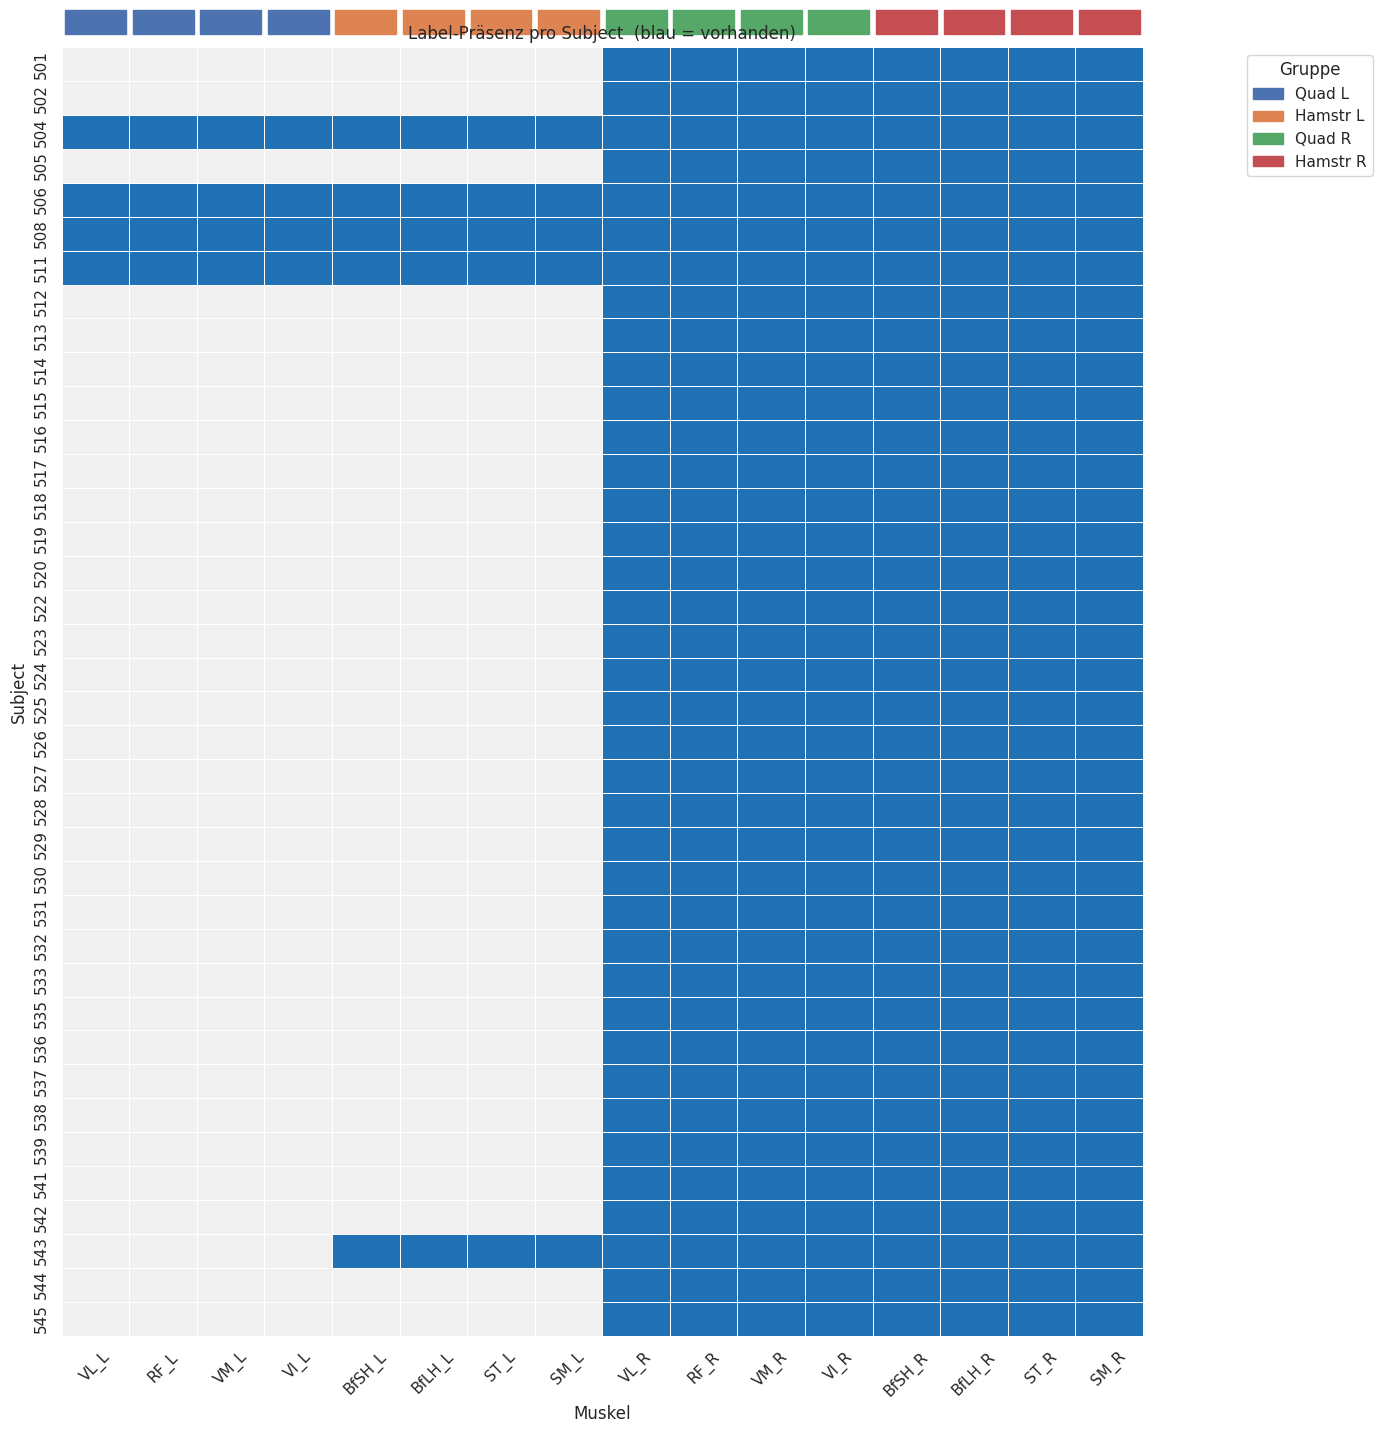

In [4]:
# Binärmatrix: Rows = Subjects, Cols = Muskeln
presence = pd.DataFrame(
    {sid: {LABEL_NAMES[l]: int(l in subj_lbls[sid]) for l in MUSCLE_LABELS}
     for sid in sids}
).T
presence.index.name = 'subject'

# Heatmap
fig, ax = plt.subplots(figsize=(14, max(5, len(sids) * 0.38)))
sns.heatmap(presence.astype(int), ax=ax, cmap=['#f0f0f0','#2171b5'],
            cbar=False, linewidths=0.4, linecolor='white')
ax.set_title('Label-Präsenz pro Subject  (blau = vorhanden)', fontsize=12)
ax.set_xlabel('Muskel')
ax.set_ylabel('Subject')
ax.tick_params(axis='x', rotation=45)

# Farbband unter den Spaltenbezeichnungen
for i, l in enumerate(MUSCLE_LABELS):
    ax.add_patch(mpatches.FancyBboxPatch(
        (i + 0.05, -1.1), 0.9, 0.7,
        boxstyle='square,pad=0',
        color=GROUP_COL[muscle_group(l)],
        transform=ax.transData, clip_on=False, zorder=3))

patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
ax.legend(handles=patches, loc='upper right', bbox_to_anchor=(1.22, 1), title='Gruppe')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_presence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Was man sieht:** Eine Heatmap mit Subjects als Zeilen und Muskeln als Spalten. Blaue Felder bedeuten, dass der Muskel für dieses Subject annotiert ist; graue Felder bedeuten, dass das Label fehlt. Die Farbbänder unter den Spaltennamen zeigen die Muskelgruppe (Blau = Quadrizeps links, Orange = Hamstrings links, Grün = Quadrizeps rechts, Rot = Hamstrings rechts).

**Was das bedeutet:**
- Die **linken Quadrizeps-Spalten** (VL_L–VI_L) sind bei **34 von 38** Subjects grau — links annotiert nur bei 504, 506, 508, 511.
- Die **rechten Muskeln** (9–16) sind bei **allen 38 Subjects** blau — durch die `_right`-Dateien.
- Subject **543**: linke Hamstrings (5–8) vorhanden, linke Quads (1–4) fehlen.
- Für das **rechte Bein-Training** (DLBS, 10 Subjects) ist die Label-Abdeckung damit nahezu vollständig; die Asymmetrie betrifft vor allem die linke Seite.

In [5]:
# Zusammenfassung bilateral vs. nur links
n_bi = (id_table['bilateral'] == 'Ja').sum()
print(f'Subjects gesamt       : {len(sids)}')
print(f'  Bilateral annotiert : {n_bi}')
print(f'  Nur links annotiert : {len(sids) - n_bi}')
print()
print('Subjects mit vollständig bilateral (alle 16 Label):')
full16 = [s for s in sids if len(subj_lbls[s]) == 16]
print(' ', full16 if full16 else 'keine')
print()
print('Subjects mit unvollständigem Label-Set (weder 8 noch 16):')
partial = [s for s in sids if len(subj_lbls[s]) not in (8, 16)]
for s in partial:
    print(f'  {s}: {subj_lbls[s]}')

Subjects gesamt       : 38
  Bilateral annotiert : 38
  Nur links annotiert : 0

Subjects mit vollständig bilateral (alle 16 Label):
  ['504', '506', '508', '511']

Subjects mit unvollständigem Label-Set (weder 8 noch 16):
  543: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


**Was man sieht:** Eine Zusammenfassung, wie viele Subjects bilateral vs. nur links annotiert sind, welche Subjects alle 16 Labels haben und welche ein unvollständiges Label-Set besitzen.

**Was das bedeutet:**
- **38/38 Subjects** haben rechte Labels in der Union; **0** nur-links.
- **4 Subjects** mit vollständigem 16-Label-Set: 504, 506, 508, 511.
- Nur **543** hat ein unvollständiges Set (12 Labels: Hamstrings links 5–8 + alle rechten 9–16); für rechts-basiertes Training unkritisch.

---
## 3 · Bildgeometrie – Shapes & Voxelgrössen

In [6]:
primary = inv[~inv['is_right_file']].copy()

shapes = pd.DataFrame(primary['shape'].tolist(),   columns=['X','Y','Z'], index=primary['subject'].values)
zooms  = pd.DataFrame(primary['vox_mm'].tolist(),  columns=['dx','dy','dz'], index=primary['subject'].values)

print('=== Shapes (Häufigkeit) ===')
print(shapes.value_counts().to_string())
print()
print('=== In-plane Voxelgrösse ===')
print(zooms[['dx','dy']].value_counts().to_string())
print()
print('=== Slice-Dicke (dz) ===')
print(zooms['dz'].value_counts().to_string())
print()
print('=== Z-Dim (# Schichten) ===')
print(shapes['Z'].describe().round(0))

=== Shapes (Häufigkeit) ===
X    Y    Z  
704  508  640    35
          626     3

=== In-plane Voxelgrösse ===
dx     dy   
0.653  0.653    38

=== Slice-Dicke (dz) ===
dz
2.0    38

=== Z-Dim (# Schichten) ===
count     38.0
mean     639.0
std        4.0
min      626.0
25%      640.0
50%      640.0
75%      640.0
max      640.0
Name: Z, dtype: float64


**Was man sieht:** Häufigkeitstabellen für Bildgrösse (Shape), In-plane Voxelgrösse und Schichtdicke sowie eine Statistik der Z-Dimension.

**Was das bedeutet:**
- **Fast alle Subjects** haben dieselbe Shape `(704, 508, 640)` — nur 3 haben 626 Schichten statt 640. Das ist sehr homogen.
- Die **In-plane Auflösung** ist bei allen identisch: `0.653 × 0.653 mm` — kein Resampling nötig.
- Die **Schichtdicke** ist bei allen `2.0 mm` — das ist anisotrop, d.h. die Auflösung in Z-Richtung ist ~3× gröber als in der Fläche. Das muss beim 3D-Netz beachtet werden (z.B. anisotrope Kernel oder 2D-Slicing-Ansatz).
- **Fazit:** Die Geometrie ist fast perfekt einheitlich — ideal für das Training ohne aufwändige Vorverarbeitung.

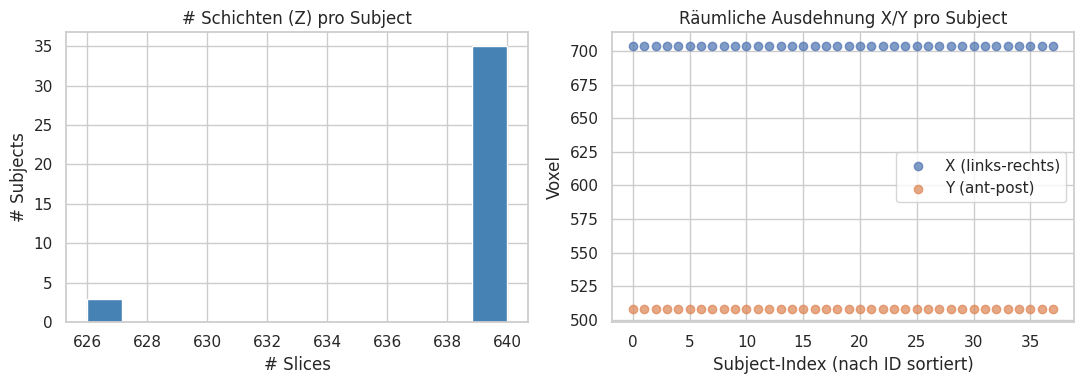

Voxelvolumen: [0.852818] mm³


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(shapes['Z'].values, bins=12, color='steelblue', edgecolor='white')
axes[0].set_title('# Schichten (Z) pro Subject')
axes[0].set_xlabel('# Slices');  axes[0].set_ylabel('# Subjects')

x_pos = range(len(shapes))
axes[1].scatter(x_pos, shapes['X'].values, label='X (links-rechts)', alpha=0.7)
axes[1].scatter(x_pos, shapes['Y'].values, label='Y (ant-post)', alpha=0.7)
axes[1].set_title('Räumliche Ausdehnung X/Y pro Subject')
axes[1].set_xlabel('Subject-Index (nach ID sortiert)')
axes[1].set_ylabel('Voxel')
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_geometry.png', dpi=150)
plt.show()

vox_vol = zooms['dx'] * zooms['dy'] * zooms['dz']
print(f'Voxelvolumen: {vox_vol.unique()} mm³')

**Was man sieht:** Links ein Histogramm der Anzahl Schichten (Z-Dimension) pro Subject; rechts ein Scatter-Plot der X- und Y-Ausdehnung in Voxeln pro Subject.

**Was das bedeutet:**
- Das **Histogramm** zeigt zwei Balken: fast alle Subjects haben 640 Schichten, 3 haben 626 — die Verteilung ist sehr eng, d.h. kaum Variabilität.
- Der **Scatter-Plot** zeigt, dass X (704) und Y (508) bei allen Subjects konstant sind — alle Punkte liegen exakt übereinander. Das bestätigt die perfekte Homogenität der Bildgrösse.
- Das Voxelvolumen beträgt `0.653 × 0.653 × 2.0 = 0.853 mm³` pro Voxel — konsistent über alle Subjects.

---
## 4 · Muskelvolumen pro Subject (Voxel & ml)

In [8]:
vol_rows = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    files = sorted(f for f in sid_dir.iterdir() if f.suffix == '.gz')

    counts  = {l: 0 for l in MUSCLE_LABELS}
    zoom_mm3 = None
    for fp in files:
        img = nib.load(str(fp))
        if zoom_mm3 is None:
            z = img.header.get_zooms()
            zoom_mm3 = float(z[0] * z[1] * z[2])
        arr = load_mask(fp)
        if arr is None: continue
        for l in MUSCLE_LABELS:
            counts[l] += int(np.sum(arr == l))

    for l, cnt in counts.items():
        if cnt > 0:
            vol_rows.append(dict(
                subject=sid, label=l,
                muscle=LABEL_NAMES[l],
                group=muscle_group(l),
                voxels=cnt,
                volume_ml=round(cnt * zoom_mm3 / 1000, 2)
            ))

vol = pd.DataFrame(vol_rows)
print(f'{len(vol)} (Subject, Muskel)-Paare mit Voxelanzahl > 0\n')

# Stats
stats = vol.groupby(['label','muscle','group'])['volume_ml'].agg(
    n='count', mean='mean', std='std', min='min', median='median', max='max'
).round(1).reset_index().sort_values('label')
stats

340 (Subject, Muskel)-Paare mit Voxelanzahl > 0



,label,muscle,group,n,mean,std,min,median,max
0,1,VL_L,Quad L,4,687.7,144.5,527.3,672.5,878.5
1,2,RF_L,Quad L,4,291.0,86.1,179.2,298.8,387.2
2,3,VM_L,Quad L,4,463.2,135.1,285.6,477.9,611.6
3,4,VI_L,Quad L,4,472.5,130.7,303.3,482.3,622.1
4,5,BfSH_L,Hamstr L,5,85.8,83.5,0.3,106.5,196.9
5,6,BfLH_L,Hamstr L,5,158.0,102.5,1.9,218.6,244.6
6,7,ST_L,Hamstr L,5,192.8,119.4,1.3,241.9,288.4
7,8,SM_L,Hamstr L,5,171.5,131.7,1.1,240.6,298.6
8,9,VL_R,Quad R,38,643.9,151.4,379.6,636.5,970.8
9,10,RF_R,Quad R,38,284.6,59.2,173.7,292.4,411.8


**Was man sieht:** Eine Statistiktabelle mit Mittelwert, Standardabweichung, Minimum, Median und Maximum des Muskelvolumens in ml — aufgeschlüsselt nach Muskel und Anzahl der Subjects, bei denen das Label vorhanden ist.

**Was das bedeutet:**
- **VL_L** Median **673 ml** (n=4) — grösster linker Muskel, aber nur bei 4 Subjects mit linken Quads messbar.
- **BfSH_L** Median **107 ml**, Minimum **0.3 ml** (n=5, inkl. 543) — kleinster und am variabelsten annotierte Muskel links.
- **Rechte Muskeln** (n=38): VL_R Median **637 ml**, RF_R **292 ml** — statistisch stabil über die ganze Kohorte.
- VL_L und VL_R liegen in ähnlicher Grössenordnung (~630–670 ml Median) — plausibel für symmetrische Anatomie.
- Die hohe Standardabweichung links (z.B. VL_L: ±145 ml bei n=4) ist wegen der kleinen Stichprobe weniger verlässlich als die rechten Werte (n=38).

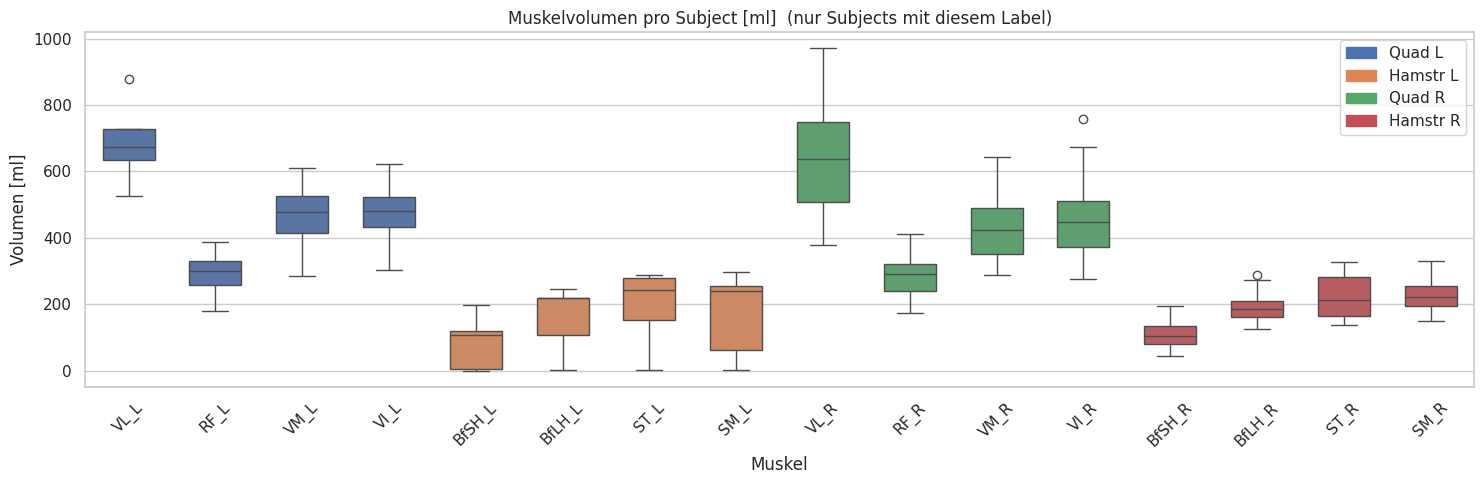

In [9]:
order   = [LABEL_NAMES[l] for l in MUSCLE_LABELS]
palette = {LABEL_NAMES[l]: GROUP_COL[muscle_group(l)] for l in MUSCLE_LABELS}

fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=vol, x='muscle', y='volume_ml', order=order,
            palette=palette, ax=ax, width=0.6)
ax.set_title('Muskelvolumen pro Subject [ml]  (nur Subjects mit diesem Label)')
ax.set_xlabel('Muskel'); ax.set_ylabel('Volumen [ml]')
ax.tick_params(axis='x', rotation=45)
patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_volume_boxplot.png', dpi=150)
plt.show()

**Was man sieht:** Ein Boxplot mit einem Kasten pro Muskel. Die Box zeigt das 25.–75. Perzentil (interquartiler Bereich), der Strich in der Mitte ist der Median, die Whisker zeigen die Gesamtspanne, und Punkte ausserhalb sind Ausreisser. Die Farbe kodiert die Muskelgruppe.

**Was das bedeutet:**
- **Quadrizeps-Muskeln (blau/grün)** sind klar grösser als Hamstrings (orange/rot) — besonders VL ist dominant.
- Die **breiten Boxen** bei VL_L und VI_L (n=4) zeigen Variabilität, sind aber statistisch wenig belastbar.
- **BfSH_L** hat den kleinsten Median und Ausreisser nahe null (u.a. Subject 543) — manuelle Prüfung sinnvoll.
- Die **rechten Muskeln** (n=38) haben enge, stabile Boxen — gute Datenlage für das aktuelle rechts-basierte DLBS-Training.
- **Für den Loss:** Imbalance VL vs. BfSH ~6:1 erfordert per-class Dice Loss oder muskelspezifische Gewichtung.

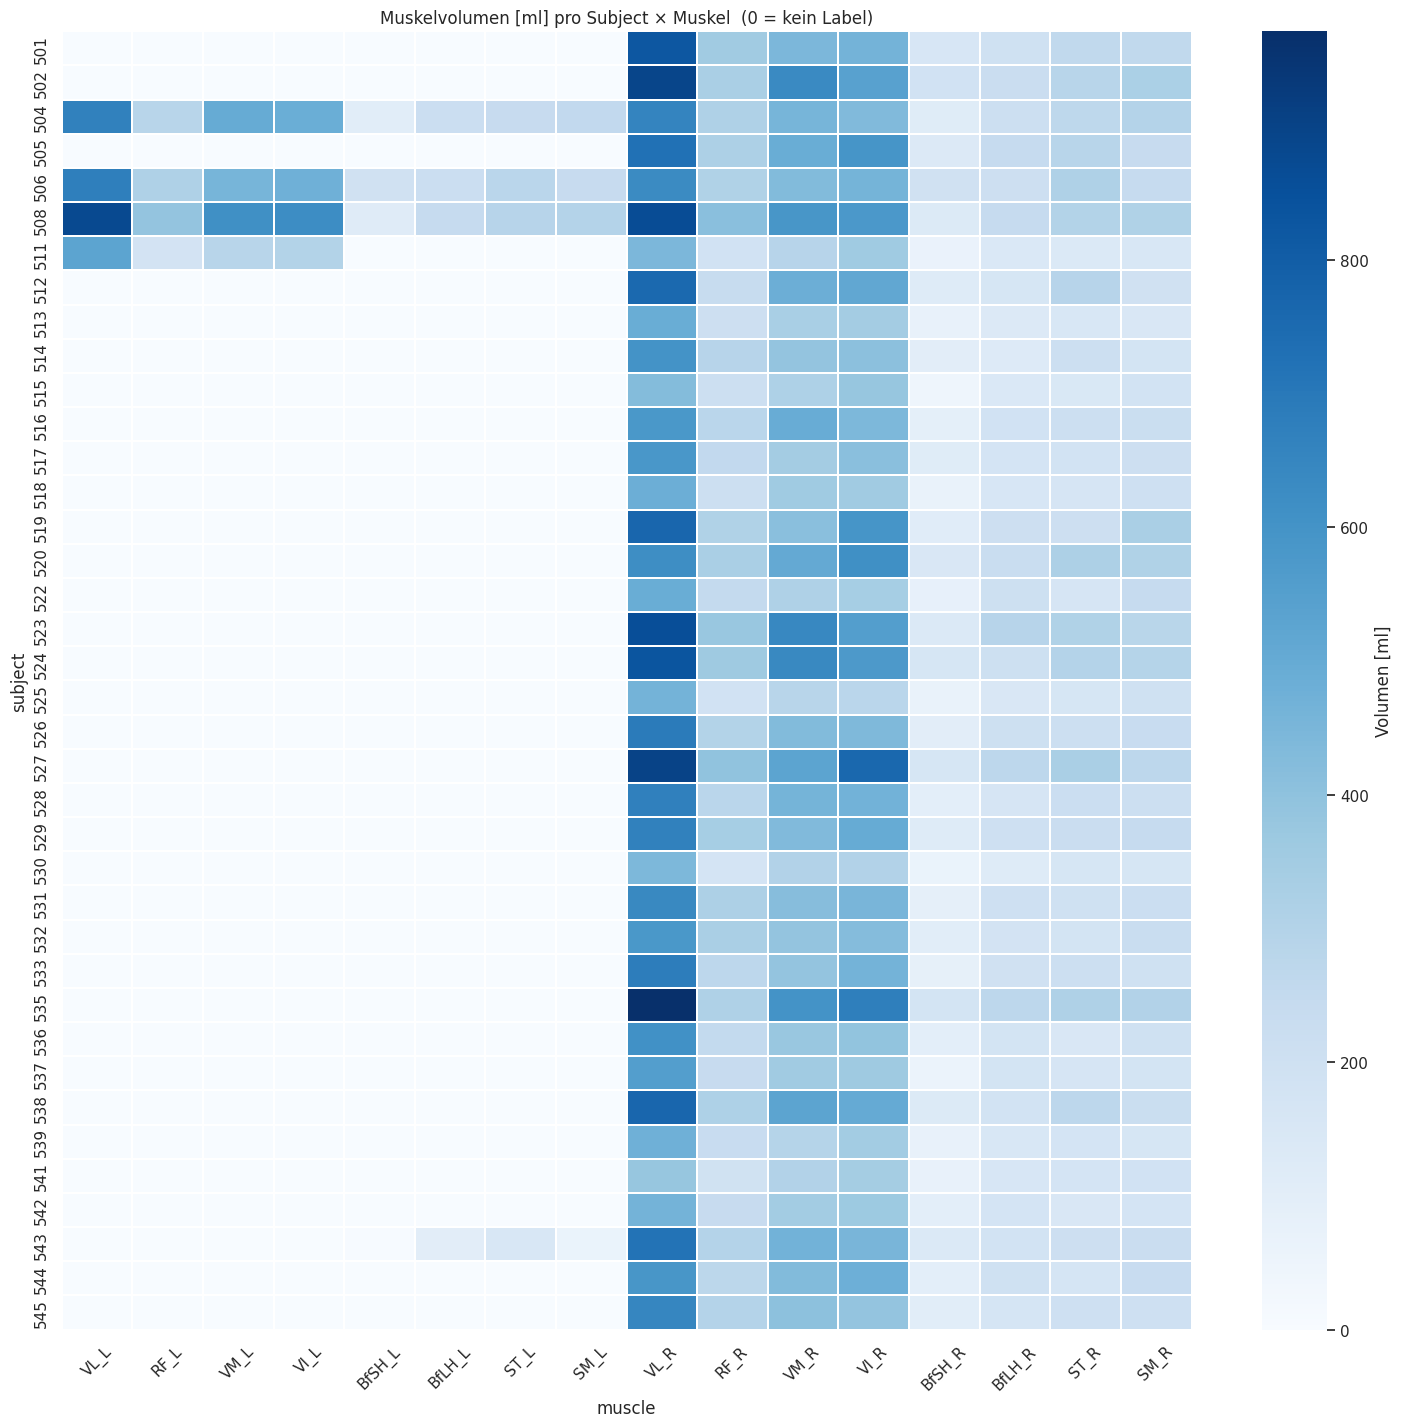

In [10]:
# Heatmap: Volumen (ml) pro Subject × Muskel
avail_muscles = [LABEL_NAMES[l] for l in MUSCLE_LABELS if LABEL_NAMES[l] in vol['muscle'].unique()]
vol_pivot = vol.pivot_table(index='subject', columns='muscle', values='volume_ml', fill_value=0)
vol_pivot = vol_pivot.reindex(columns=[m for m in avail_muscles if m in vol_pivot.columns])

fig, ax = plt.subplots(figsize=(15, max(5, len(vol_pivot) * 0.38)))
sns.heatmap(vol_pivot, ax=ax, cmap='Blues', linewidths=0.3,
            cbar_kws={'label': 'Volumen [ml]'})
ax.set_title('Muskelvolumen [ml] pro Subject × Muskel  (0 = kein Label)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_volume_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Was man sieht:** Eine Heatmap mit Subjects als Zeilen und Muskeln als Spalten. Die Farbintensität (hellblau bis dunkelblau) zeigt das Muskelvolumen in ml — weiss/leer bedeutet kein Label vorhanden.

**Was das bedeutet:**
- Die **rechten Muskeln-Spalten** (VL_R bis SM_R) sind bei **allen 38 Subjects** gefärbt — vollständige rechte Annotation.
- Die **linken Quadrizeps-Spalten** (VL_L–VI_L) sind nur bei **504, 506, 508, 511** sichtbar; bei den übrigen weiss/leer.
- **BfSH_L** erscheint als hellere Felder — kleineres Volumen als die Quads.
- Subject **543**: Hamstrings links gefärbt, linke Quads fehlen (erste vier Spalten weiss).
- Inter-subject Variabilität ist vor allem bei den rechten Muskeln gut sichtbar (dunklere vs. hellere Zeilen).

---
## 5 · Klassen-Imbalance  (Background vs. Muskeln)

In [11]:
imbal_rows = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    pfiles = [f for f in sid_dir.iterdir()
              if f.suffix == '.gz' and 'right' not in f.name.lower()]
    if not pfiles: continue
    arr = load_mask(pfiles[0])
    if arr is None: continue
    total = arr.size
    n_bg  = int(np.sum(arr == 0))
    n_m   = total - n_bg
    imbal_rows.append(dict(subject=sid, total=total, bg=n_bg,
                           muscle=n_m, muscle_pct=round(100*n_m/total, 4)))

imbal = pd.DataFrame(imbal_rows)
print(f'Muskel-Anteil (primary mask):')
print(f'  Median {imbal["muscle_pct"].median():.3f}%')
print(f'  Min    {imbal["muscle_pct"].min():.3f}%   Max {imbal["muscle_pct"].max():.3f}%')
imbal[['subject','total','bg','muscle','muscle_pct']]

Muskel-Anteil (primary mask):
  Median 1.283%
  Min    0.167%   Max 1.853%


,subject,total,bg,muscle,muscle_pct
0,501,223877632,220405607,3472025,1.5509
1,502,223877632,219872342,4005290,1.7891
2,504,223877632,220642377,3235255,1.4451
3,505,228884480,225331555,3552925,1.5523
4,506,228884480,225536195,3348285,1.4629
5,508,228884480,224842185,4042295,1.7661
6,511,228884480,227362094,1522386,0.6651
7,512,228884480,225650531,3233949,1.4129
8,513,228884480,226668614,2215866,0.9681
9,514,228884480,226182471,2702009,1.1805


**Was man sieht:** Eine Tabelle mit dem Hintergrund- und Muskelanteil pro Subject — absolut in Voxeln und relativ in Prozent.

**Was das bedeutet:**
- Der **Muskelanteil** liegt zwischen **0.17% und 1.85%**, Median **1.28%** — über 98% jedes Bildes ist Hintergrund.
- **Subject 543** hat mit **0.17%** den kleinsten Anteil — fehlende Quadrizeps-links-Labels in der Primary-Maske.
- Diese extreme Imbalance ist der **kritischste Faktor** für das Segmentierungsmodell: Ein naiver Classifier mit alles-Hintergrund hätte ~99% Pixel-Accuracy — daher Dice/IoU statt Accuracy.

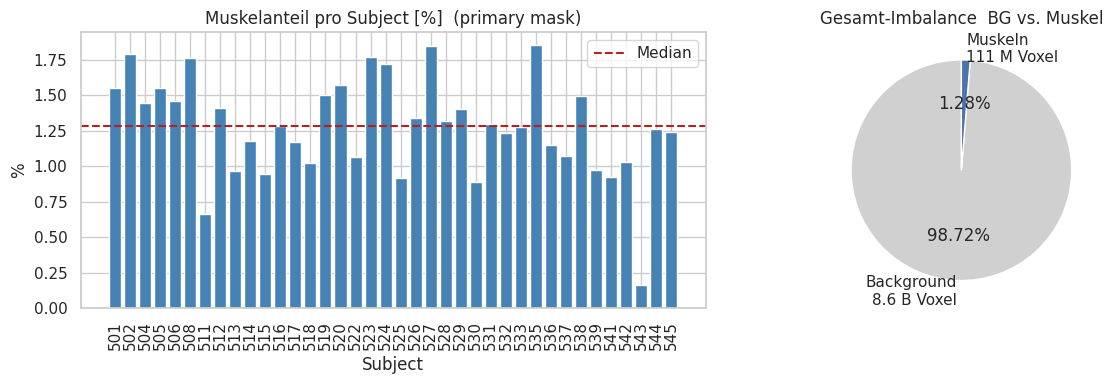


Imbalance-Ratio BG:Muskel = 77:1


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(imbal['subject'], imbal['muscle_pct'], color='steelblue')
axes[0].axhline(imbal['muscle_pct'].median(), color='firebrick', lw=1.5, ls='--', label='Median')
axes[0].set_title('Muskelanteil pro Subject [%]  (primary mask)')
axes[0].set_xlabel('Subject'); axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=90); axes[0].legend()

total_bg   = imbal['bg'].sum()
total_musc = imbal['muscle'].sum()
axes[1].pie([total_bg, total_musc],
            labels=[f'Background\n{total_bg/1e9:.1f} B Voxel',
                    f'Muskeln\n{total_musc/1e6:.0f} M Voxel'],
            colors=['#d0d0d0','#4C72B0'], autopct='%1.2f%%', startangle=90)
axes[1].set_title('Gesamt-Imbalance  BG vs. Muskel')

plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_classimbalance.png', dpi=150)
plt.show()

print(f'\nImbalance-Ratio BG:Muskel = {total_bg/total_musc:.0f}:1')

**Was man sieht:** Links ein Balkendiagramm mit dem Muskelanteil in % pro Subject (rote gestrichelte Linie = Median); rechts ein Tortendiagramm der Gesamt-Imbalance zwischen Hintergrund und Muskel-Voxeln über alle Subjects.

**Was das bedeutet:**
- Das **Balkendiagramm** zeigt die Variabilität zwischen Subjects: Die meisten liegen um **1.2–1.5%**, Ausreißer **543** mit nur **0.17%** Muskelanteil.
- Das **Tortendiagramm** macht die Imbalance visuell eindrücklich: Nur ein winziges Segment (Muskeln) steht einem riesigen Rest (Hintergrund) gegenüber. Das **Verhältnis BG:Muskel = 77:1** — auf jeden Muskel-Voxel kommen 77 Hintergrund-Voxel.
- **Konsequenzen für das Training:**
  - Dice Loss oder Focal Loss statt Standard Cross-Entropy verwenden
  - Patch-basiertes Sampling: nur Patches mit Muskelinhalt trainieren, um leere Patches zu überspringen
  - Oder Class Weights: Hintergrund mit 1/77 gewichten relativ zu Muskeln

---
## 6 · Slice-Coverage – wie viele Schichten enthält jedes Label?

In [13]:
cov_rows = []
for sid_dir in sorted(MASK_DIR.iterdir()):
    if not sid_dir.is_dir(): continue
    sid = sid_dir.name
    files = sorted(f for f in sid_dir.iterdir() if f.suffix == '.gz')

    merged = None
    n_slices = None
    for fp in files:
        arr = load_mask(fp)
        if arr is None: continue
        if merged is None:
            merged = arr.copy(); n_slices = arr.shape[2]
        else:
            fg = arr > 0; merged[fg] = arr[fg]

    if merged is None: continue

    for l in MUSCLE_LABELS:
        per_slice = np.any(merged == l, axis=(0, 1))
        n_with    = int(per_slice.sum())
        if n_with > 0:
            zidx = np.where(per_slice)[0]
            cov_rows.append(dict(
                subject=sid, label=l,
                muscle=LABEL_NAMES[l],
                group=muscle_group(l),
                n_slices_total=n_slices,
                n_slices_label=n_with,
                coverage_pct=round(100 * n_with / n_slices, 1),
                z_min=int(zidx.min()), z_max=int(zidx.max()),
                z_span=int(zidx.max() - zidx.min() + 1)
            ))

cov = pd.DataFrame(cov_rows)
print('Coverage-Statistik pro Muskel:')
cov.groupby(['label','muscle'])['coverage_pct'].agg(
    n='count', mean='mean', std='std', min='min', max='max'
).round(1)

Coverage-Statistik pro Muskel:


,,n,mean,std,min,max
label,muscle,,,,,
1,VL_L,4,27.7,2.9,24.2,31.2
2,RF_L,4,26.3,2.4,24.4,29.7
3,VM_L,4,25.7,2.2,22.8,28.0
4,VI_L,4,27.9,2.1,26.2,30.6
5,BfSH_L,5,12.7,9.9,0.2,20.6
6,BfLH_L,5,15.5,9.9,0.2,24.2
7,ST_L,5,18.6,11.3,0.2,27.5
8,SM_L,5,14.4,9.9,0.2,23.3
9,VL_R,38,25.9,1.9,20.5,29.2


**Was man sieht:** Eine Tabelle mit der Slice-Coverage pro Muskel: wie viele Subjects haben diesen Muskel (n), welcher Prozentsatz der Schichten enthält den Muskel im Durchschnitt, sowie Minimum und Maximum.

**Was das bedeutet:**
- **Linke Quads** (n=4): ca. **24–28%** Slice-Coverage — erstrecken sich über einen grösseren Z-Bereich.
- **Hamstrings links** (n=5): **13–19%** Coverage, Minimum **0.2%** bei 543 — deutlich kompakter und teils lückenhaft annotiert.
- **Rechte Muskeln** (n=38): **20–27%** Coverage, engere Verteilung (Std ~1.6–2.0%) — konsistente Annotation über die Kohorte.
- **Praktische Konsequenz:** Muskeln liegen nur in ~20–28% der Schichten; Z-Cropping auf den Muskelbereich spart Rechenzeit.

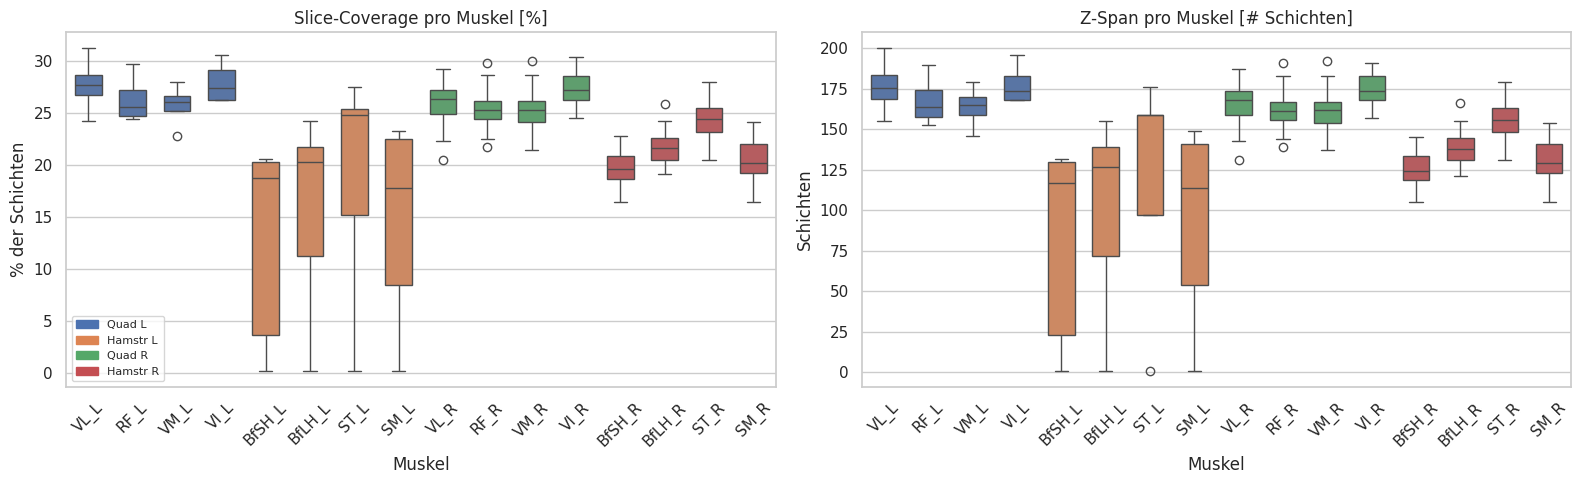

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order_avail = [LABEL_NAMES[l] for l in MUSCLE_LABELS if LABEL_NAMES[l] in cov['muscle'].unique()]
palette_avail = {m: GROUP_COL[muscle_group(l)]
                 for l in MUSCLE_LABELS for m in [LABEL_NAMES[l]] if m in order_avail}

sns.boxplot(data=cov, x='muscle', y='coverage_pct', order=order_avail,
            palette=palette_avail, ax=axes[0], width=0.6)
axes[0].set_title('Slice-Coverage pro Muskel [%]')
axes[0].set_xlabel('Muskel'); axes[0].set_ylabel('% der Schichten')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=cov, x='muscle', y='z_span', order=order_avail,
            palette=palette_avail, ax=axes[1], width=0.6)
axes[1].set_title('Z-Span pro Muskel [# Schichten]')
axes[1].set_xlabel('Muskel'); axes[1].set_ylabel('Schichten')
axes[1].tick_params(axis='x', rotation=45)

patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
axes[0].legend(handles=patches, fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_slice_coverage.png', dpi=150)
plt.show()

**Was man sieht:** Zwei nebeneinander liegende Boxplots — links die Slice-Coverage in Prozent, rechts der Z-Span (Anzahl Schichten, über die sich der Muskel erstreckt) — je Muskel.

**Was das bedeutet:**
- Der **linke Boxplot (Coverage %)** zeigt: Rechte Quads ~25–27%, Hamstrings rechts ~20–22%; links nur bei n=4–5 Subjects, daher breitere Boxen.
- **VI_R** hat mit ~27% die höchste mittlere Coverage unter den rechten Muskeln.
- Der **rechte Boxplot (Z-Span)** bestätigt: Bei ~640 Schichten gesamt entspricht Z-Span proportional der Coverage.
- Rechte Muskeln (n=38) haben **enge Boxen** — homogener Muskelverlauf; linke Werte sind wegen kleiner n weniger belastbar.
- **Implikation:** Z-Bereich pro Subject dynamisch aus der Maske bestimmen, nicht fest wählen.

---
## 7 · Label-Imbalance zwischen den Muskeln (relative Grösse)

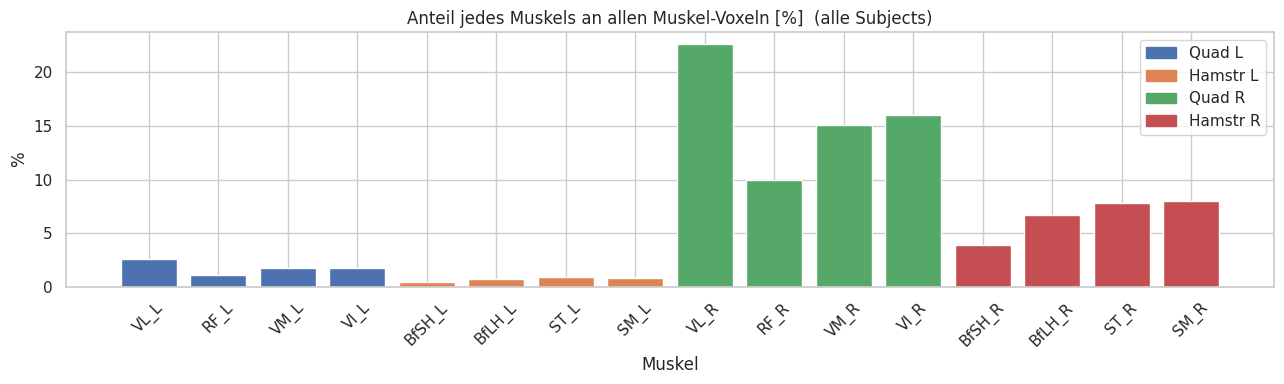

muscle   voxels  pct_of_all_muscle
  VL_L  3221574               2.54
  RF_L  1363171               1.08
  VM_L  2169984               1.71
  VI_L  2213631               1.75
BfSH_L   502231               0.40
BfLH_L   925448               0.73
  ST_L  1128967               0.89
  SM_L  1004309               0.79
  VL_R 28656049              22.62
  RF_R 12664572               9.99
  VM_R 19116853              15.09
  VI_R 20332747              16.05
BfSH_R  4917905               3.88
BfLH_R  8487698               6.70
  ST_R  9839834               7.77
  SM_R 10167231               8.02


In [15]:
# Gesamtvoxel pro Muskel (alle Subjects summiert)
total_per_muscle = vol.groupby(['label','muscle','group'])['voxels'].sum().reset_index()
total_per_muscle = total_per_muscle.sort_values('label')
total_per_muscle['pct_of_all_muscle'] = (
    100 * total_per_muscle['voxels'] / total_per_muscle['voxels'].sum()
).round(2)

fig, ax = plt.subplots(figsize=(13, 4))
colors = [GROUP_COL[g] for g in total_per_muscle['group']]
bars = ax.bar(total_per_muscle['muscle'], total_per_muscle['pct_of_all_muscle'],
              color=colors, edgecolor='white')
ax.set_title('Anteil jedes Muskels an allen Muskel-Voxeln [%]  (alle Subjects)')
ax.set_xlabel('Muskel'); ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=45)
patches = [mpatches.Patch(color=c, label=g) for g, c in GROUP_COL.items()]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(RESULTS / 'eda_seg_label_share.png', dpi=150)
plt.show()

print(total_per_muscle[['muscle','voxels','pct_of_all_muscle']].to_string(index=False))

**Was man sieht:** Ein Balkendiagramm, das den prozentualen Anteil jedes Muskels an der Gesamtzahl aller Muskel-Voxel über alle Subjects zeigt. Die Farbe kodiert die Muskelgruppe.

**Was das bedeutet:**
- **VL_R (22.6%)** dominiert — grosses Volumen × 38 Subjects mit `_right`-Maske.
- **Rechte Muskeln** machen zusammen ~**90%** aller Muskel-Voxel aus; linke Labels nur ~**10%** (wenige Subjects mit linken Quads).
- Unter den linken Muskeln ist **BfSH_L (0.4%)** am stärksten unterrepräsentiert.
- Die Dominanz der rechten Seite spiegelt die **Dateistruktur** (`_right`-Dateien für alle 38 Subjects), nicht unbedingt anatomische Asymmetrie.
- **Per-class Dice Loss** ist wichtig, damit kleine Muskeln (BfSH) nicht von VL überdeckt werden.

---
## 8 · Zusammenfassung – relevante Kennzahlen für Segmentierungsmodell

In [16]:
n_bi = (id_table['bilateral'] == 'Ja').sum()

print('=' * 60)
print('DATASET-ÜBERSICHT')
print('=' * 60)
print(f'  Subjects gesamt          : {len(sids)}')
print(f'  Davon bilateral annotiert: {n_bi}')
print(f'  Davon nur links          : {len(sids) - n_bi}')
print()
print('BILDGEOMETRIE')
print(f'  Voxelgrösse (typisch)    : 0.65 × 0.65 × 2.0 mm')
print(f'  In-plane Auflösung       : 704 × 508 Voxel')
print(f'  Anzahl Schichten (Z)     : {shapes["Z"].min():.0f} – {shapes["Z"].max():.0f}')
print()
print('KLASSEN')
print(f'  Klassen gesamt (inkl. BG): 17  (BG + 8 links + 8 rechts)')
print(f'  Imbalance-Ratio BG:Muskel: {total_bg/total_musc:.0f}:1')
print(f'  Muskel-Anteil (Median)   : {imbal["muscle_pct"].median():.3f}% der Voxel')
print()
print('VOLUMEN PRO MUSKEL (Median über alle Subjects mit diesem Label)')
for _, row in stats.iterrows():
    print(f'  {row["muscle"]:8s}  {row["median"]:6.1f} ml   '
          f'[{row["min"]:.0f} – {row["max"]:.0f}]   (n={int(row["n"])} Subjects)')
print('=' * 60)

DATASET-ÜBERSICHT
  Subjects gesamt          : 38
  Davon bilateral annotiert: 38
  Davon nur links          : 0

BILDGEOMETRIE
  Voxelgrösse (typisch)    : 0.65 × 0.65 × 2.0 mm
  In-plane Auflösung       : 704 × 508 Voxel
  Anzahl Schichten (Z)     : 626 – 640

KLASSEN
  Klassen gesamt (inkl. BG): 17  (BG + 8 links + 8 rechts)
  Imbalance-Ratio BG:Muskel: 77:1
  Muskel-Anteil (Median)   : 1.283% der Voxel

VOLUMEN PRO MUSKEL (Median über alle Subjects mit diesem Label)
  VL_L       672.5 ml   [527 – 878]   (n=4 Subjects)
  RF_L       298.8 ml   [179 – 387]   (n=4 Subjects)
  VM_L       477.9 ml   [286 – 612]   (n=4 Subjects)
  VI_L       482.3 ml   [303 – 622]   (n=4 Subjects)
  BfSH_L     106.5 ml   [0 – 197]   (n=5 Subjects)
  BfLH_L     218.6 ml   [2 – 245]   (n=5 Subjects)
  ST_L       241.9 ml   [1 – 288]   (n=5 Subjects)
  SM_L       240.6 ml   [1 – 299]   (n=5 Subjects)
  VL_R       636.5 ml   [380 – 971]   (n=38 Subjects)
  RF_R       292.4 ml   [174 – 412]   (n=38 Subjects)
 

**Was man sieht:** Eine kompakte Übersicht der wichtigsten Kennzahlen des Datensatzes — Subjects, Bildgeometrie, Klassenverteilung und Volumina pro Muskel.

**Was das bedeutet — die 5 wichtigsten Erkenntnisse für das Segmentierungsmodell:**

1. **Kohorte:** **38 Subjects** in `cleaned_data_2`; DLBS-Training auf **10 Subjects** (rechtes Bein, 3-Fold CV) — Data Augmentation und CV sind essenziell.

2. **Label-Asymmetrie:** Rechte Labels (9–16) bei **allen 38** Subjects; linke Quads (1–4) nur bei **4**. DLBS trainiert **rechts** — gute Label-Abdeckung für die Baseline.

3. **Extreme Klassen-Imbalance (BG ≫ Muskel, 77:1):** Dice Loss oder Focal Loss zwingend. Pixel-Accuracy wertlos — immer Dice/IoU pro Klasse berichten.

4. **Einheitliche Geometrie:** 704×508 in-plane, Z 626–640, Voxel **0.65×0.65×2.0 mm** — feste Patch-Grösse `[128,128,32]` möglich; anisotrope Auflösung in Z beachten.

5. **Subject 543:** Einziges unvollständiges Subject (Hamstrings links + rechts, keine Quads links). Für rechts-Training unkritisch; bei links-Training ausschliessen oder maskierten Loss verwenden.